# Supervised Learning: Regression

# What is Linear Regression?

<p>In supervised learning, there is the goal of predicting an outcome based on a set of input measures. Linear regression takes a set of inputs $X$ and a set of outputs $y$, and models a linear relationship by which the input maximally explains the output. It predicts a target as a weighted sum of feature inputs, and the weight attached to each feature's inputs is called a coefficient. For a single instance, the relationship can be written as:</p>

<p>$$y = \beta_0 + \beta_1 x1 + \beta_2 x_2 + ... + \beta_p x_p + \epsilon$$</p>
    <ul>
        <li>$y$ is the numeric response for the instance in question</li>
        <li>$\beta_0$ is an estimated intercept value</li>
        <li>$b_p$ is the estimated coefficient for the $p^th$ variable</li>
        <li>$\epsilon$ is random error that cannot be explained by the model</li>
    </ul>

# Interpretation

<p>Linear regression models are interpretable on a modular level. An advantage to models that follow a regression formula is that they are highly interpretable. Another advantage is that their nature allows us to compute standard errors of the coefficients. Assumptions apply, but are often violated with little consequence. These assumptions include:</p>
<ul>
    <li>A linear (uncurved) effect</li>
    <li>A constant/stationary level of variance throughout the dataset (homoscedasticity)</li>
    <li>Independence of errors</li>
    <li>Lack of correlated features</li>
    <li>Normally distributed errors</li>
</ul>

# Simple Linear Regression Implementation

We'll import some necessary libraries,

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from math import sqrt

Then generate some data that is correlated, but contains some random noise.

In [2]:
N = 100

x = np.random.randn(N)
y = x + np.random.randn(N)

The sk-learn model we'll be using requires the second dimensions to be explicit, which we can achieve with <code>reshape()</code>

In [3]:
x = x.reshape(-1,1)
y = y.reshape(-1,1)

print(np.shape(x))
print(np.shape(y))

(100, 1)
(100, 1)


Finally, we'll fit the model and print the intercept and coefficient.

In [4]:
model = linear_model.LinearRegression()
_ = model.fit(x,y)

print("y_hat = " + str(round(model.intercept_[0],5)) + " + " \
      + str(round(model.coef_[0][0],5)) + " x1")

y_hat = 0.07101 + 1.10159 x1


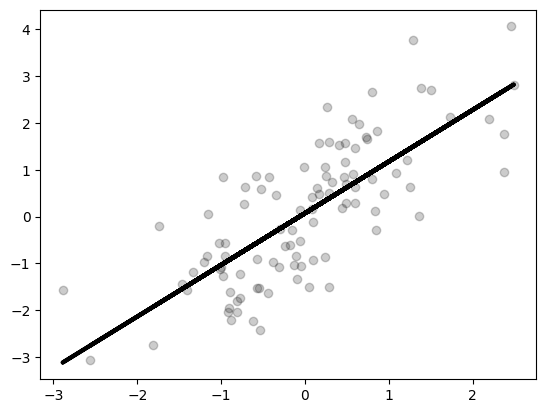

In [5]:
pred = model.predict(x)
plt.scatter(x, y, color='black', alpha=0.2);
plt.plot(x, pred, color='black', linewidth=3);

# Evaluating Correlation

One way of evaluating results is by the correlation between the predictions and the actual y values. A correlation analysis outputs a correlation coefficient $r$ (a.k.a. Pearson's correlation coefficient) that shows the linear relationship between two variables, and varies between -1 (a perfectly negative correlation) and +1 (a perfectly positive correlation).

Correlation is covariance scaled by the standard deviation of both data items, and covariance is an unscaled number that measures the linear relationship between two variables (ranging from $-X$ to $+X$).

The formula for <b>covariance</b> is as follows:
    
$$cov(x,y)=\frac{\sum_{i=1}^{N}(x_{i}-\bar{x})(y_{i}-\bar{y})}{N-1}$$

An implementation of this exists in Numpy. It returns a matrix, comparing each variable to each other variable.

<b>Correlation</b> is calculated as follows:
    
$$r = \frac{ \sum_(x_i - \bar{x})(y_i - \bar{y}) }{ (n-1) s_x s_y }$$

where $s_x$ and $s_y$ are the standard deviations of $x$ and $y$ respectively.

Again, we don't have to calculate it manually because a reliable implementation exists in Numpy. The function requires that we eliminate the second dimension of 1 that we made explicit, and this can be done using Numpy's squeeze function.

In [6]:
from scipy.stats import pearsonr

r = pearsonr(y.squeeze(),pred.squeeze())
r

PearsonRResult(statistic=0.7546273432379266, pvalue=1.2325471754873224e-19)

The correlation is quite strong, at 0.67, and the p-value shows significance. A nice feature of correlation is that it is on a scale comparable amongst data sets. It is, however, sensitive to outliers.

# Multiple Linear Regression

When multiple independent variables are being considered, we call it multiple regression. Each independent variable receives a coefficient (including a confidence range) which describes it's contribution to the model.

### The Abalone Dataset

Time to load our dataset. The Abalone dataset comes from a 1994 study, "The Population Biology of Abalone", focusing on Tasmania's North Coast and Islands of the Bass Straits. Abalone are marine snails, the flesh of which is considered a desirable food, and the shells of which are highly iridescent, which people have attractive as decorative objects and jewelry.

The age of Abalone is determined by cutting the shell through the core, staining it, and counting the number of rings (plus a constant of 1.5). The objective of this case study is to use the known data to predict age based on other features, as this is far less time-consuming than counting the rings. We will explore regression based methods of prediction.

The data includes sex, categorized as male, female, and infant. Also included are 3 measures of size (length, width, diameter) and 4 measures of weight (whole, shucked, viscera, and shell weight).

<img src="https://github.com/pw598/Legacy-Notebooks/blob/main/img/abalone.jpeg?raw=true" style="height: 500px; width: auto;">

### Import Libraries and Data

We'll import seaborn for visualization, and turn off warnings.

In [7]:
import seaborn as sns
sns.set_theme(style="darkgrid")

import warnings
warnings.filterwarnings("ignore")

Next, import the data.

In [8]:
df = pd.read_csv("abalone.csv")

Then let's take a look at the data.

In [9]:
df.shape

(4177, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4177 non-null   object 
 1   length          4177 non-null   float64
 2   diam            4177 non-null   float64
 3   height          4177 non-null   float64
 4   weight          4177 non-null   float64
 5   shucked_weight  4177 non-null   float64
 6   viscera_weight  4177 non-null   float64
 7   shell_weight    4177 non-null   float64
 8   age             4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [11]:
df.head()

,sex,length,diam,height,weight,shucked_weight,viscera_weight,shell_weight,age
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


# Exploratory Data Analysis

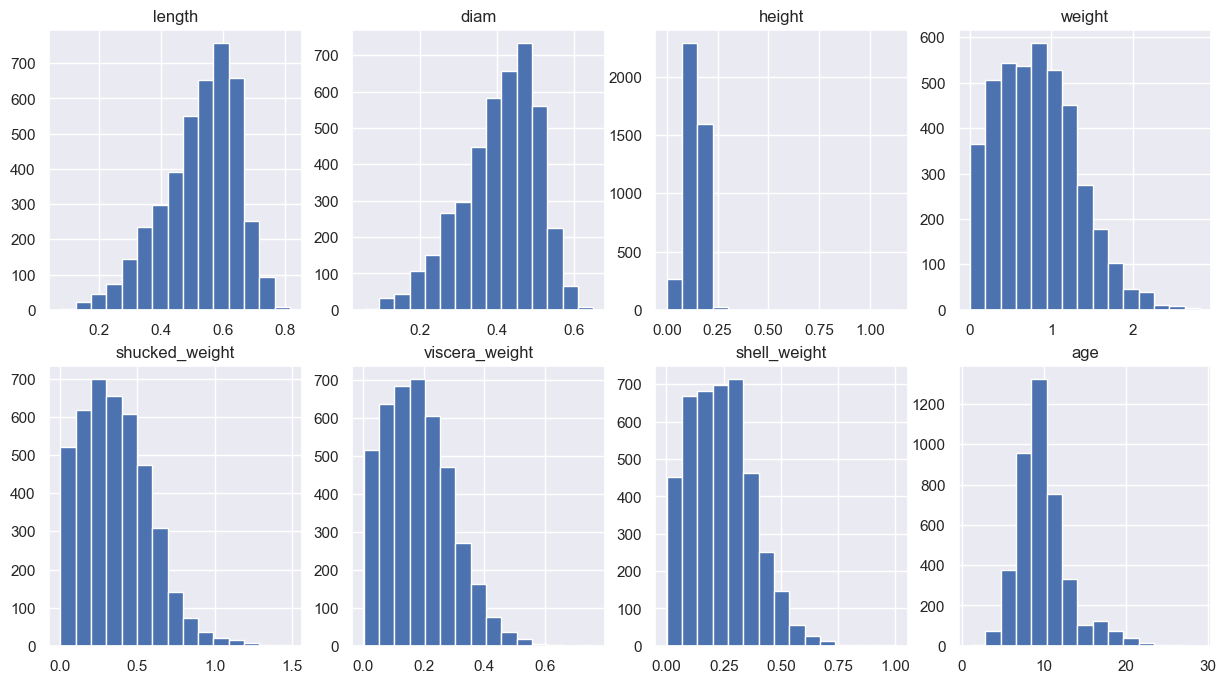

In [12]:
fig, ax = plt.subplots(2, 4, figsize = (15, 8))

k = 15

ax[0][0].hist(df["length"], bins=k)
ax[0][0].set_title("length")

ax[0][1].hist(df["diam"], bins = k)
ax[0][1].set_title("diam")

ax[0][2].hist(df["height"], bins = k)
ax[0][2].set_title("height")

ax[0][3].hist(df["weight"], bins = k)
ax[0][3].set_title('weight')

ax[1][0].hist(df["shucked_weight"], bins=k)
ax[1][0].set_title("shucked_weight")

ax[1][1].hist(df["viscera_weight"], bins = k)
ax[1][1].set_title("viscera_weight")

ax[1][2].hist(df["shell_weight"], bins = k)
ax[1][2].set_title("shell_weight")

ax[1][3].hist(df["age"], bins = k)
ax[1][3].set_title('age')

plt.show()

In [13]:
df[df['height'] > 0.25]

,sex,length,diam,height,weight,shucked_weight,viscera_weight,shell_weight,age
1417,M,0.705,0.565,0.515,2.210,1.1075,0.4865,0.5120,10
2051,F,0.455,0.355,1.130,0.594,0.3320,0.1160,0.1335,8


We can see that two observations are outliers in terms of height, causing the skewed distribution. We will simply remove these ourlier observations.

In [14]:
df = df[df['height'] < 0.5]

Then inspect the revised distribution.

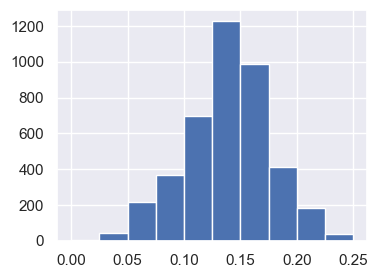

In [15]:
df['height'].hist(figsize=(4,3));

Next, a correlation matrix.

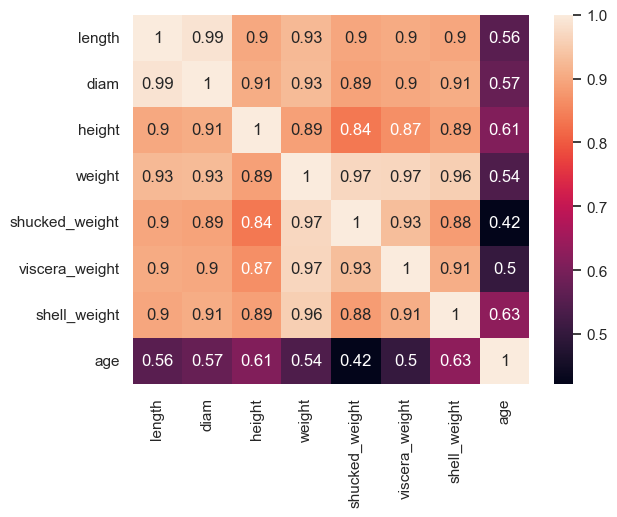

In [16]:
df2 = df.drop(['sex'], axis=1)
sns.heatmap(df2.corr(), annot=True);

We see that our independent variables are quite correlated with each other, and tend to have moderate correlation with the independent variable. A pair plot will provide a finer view of these relationships.

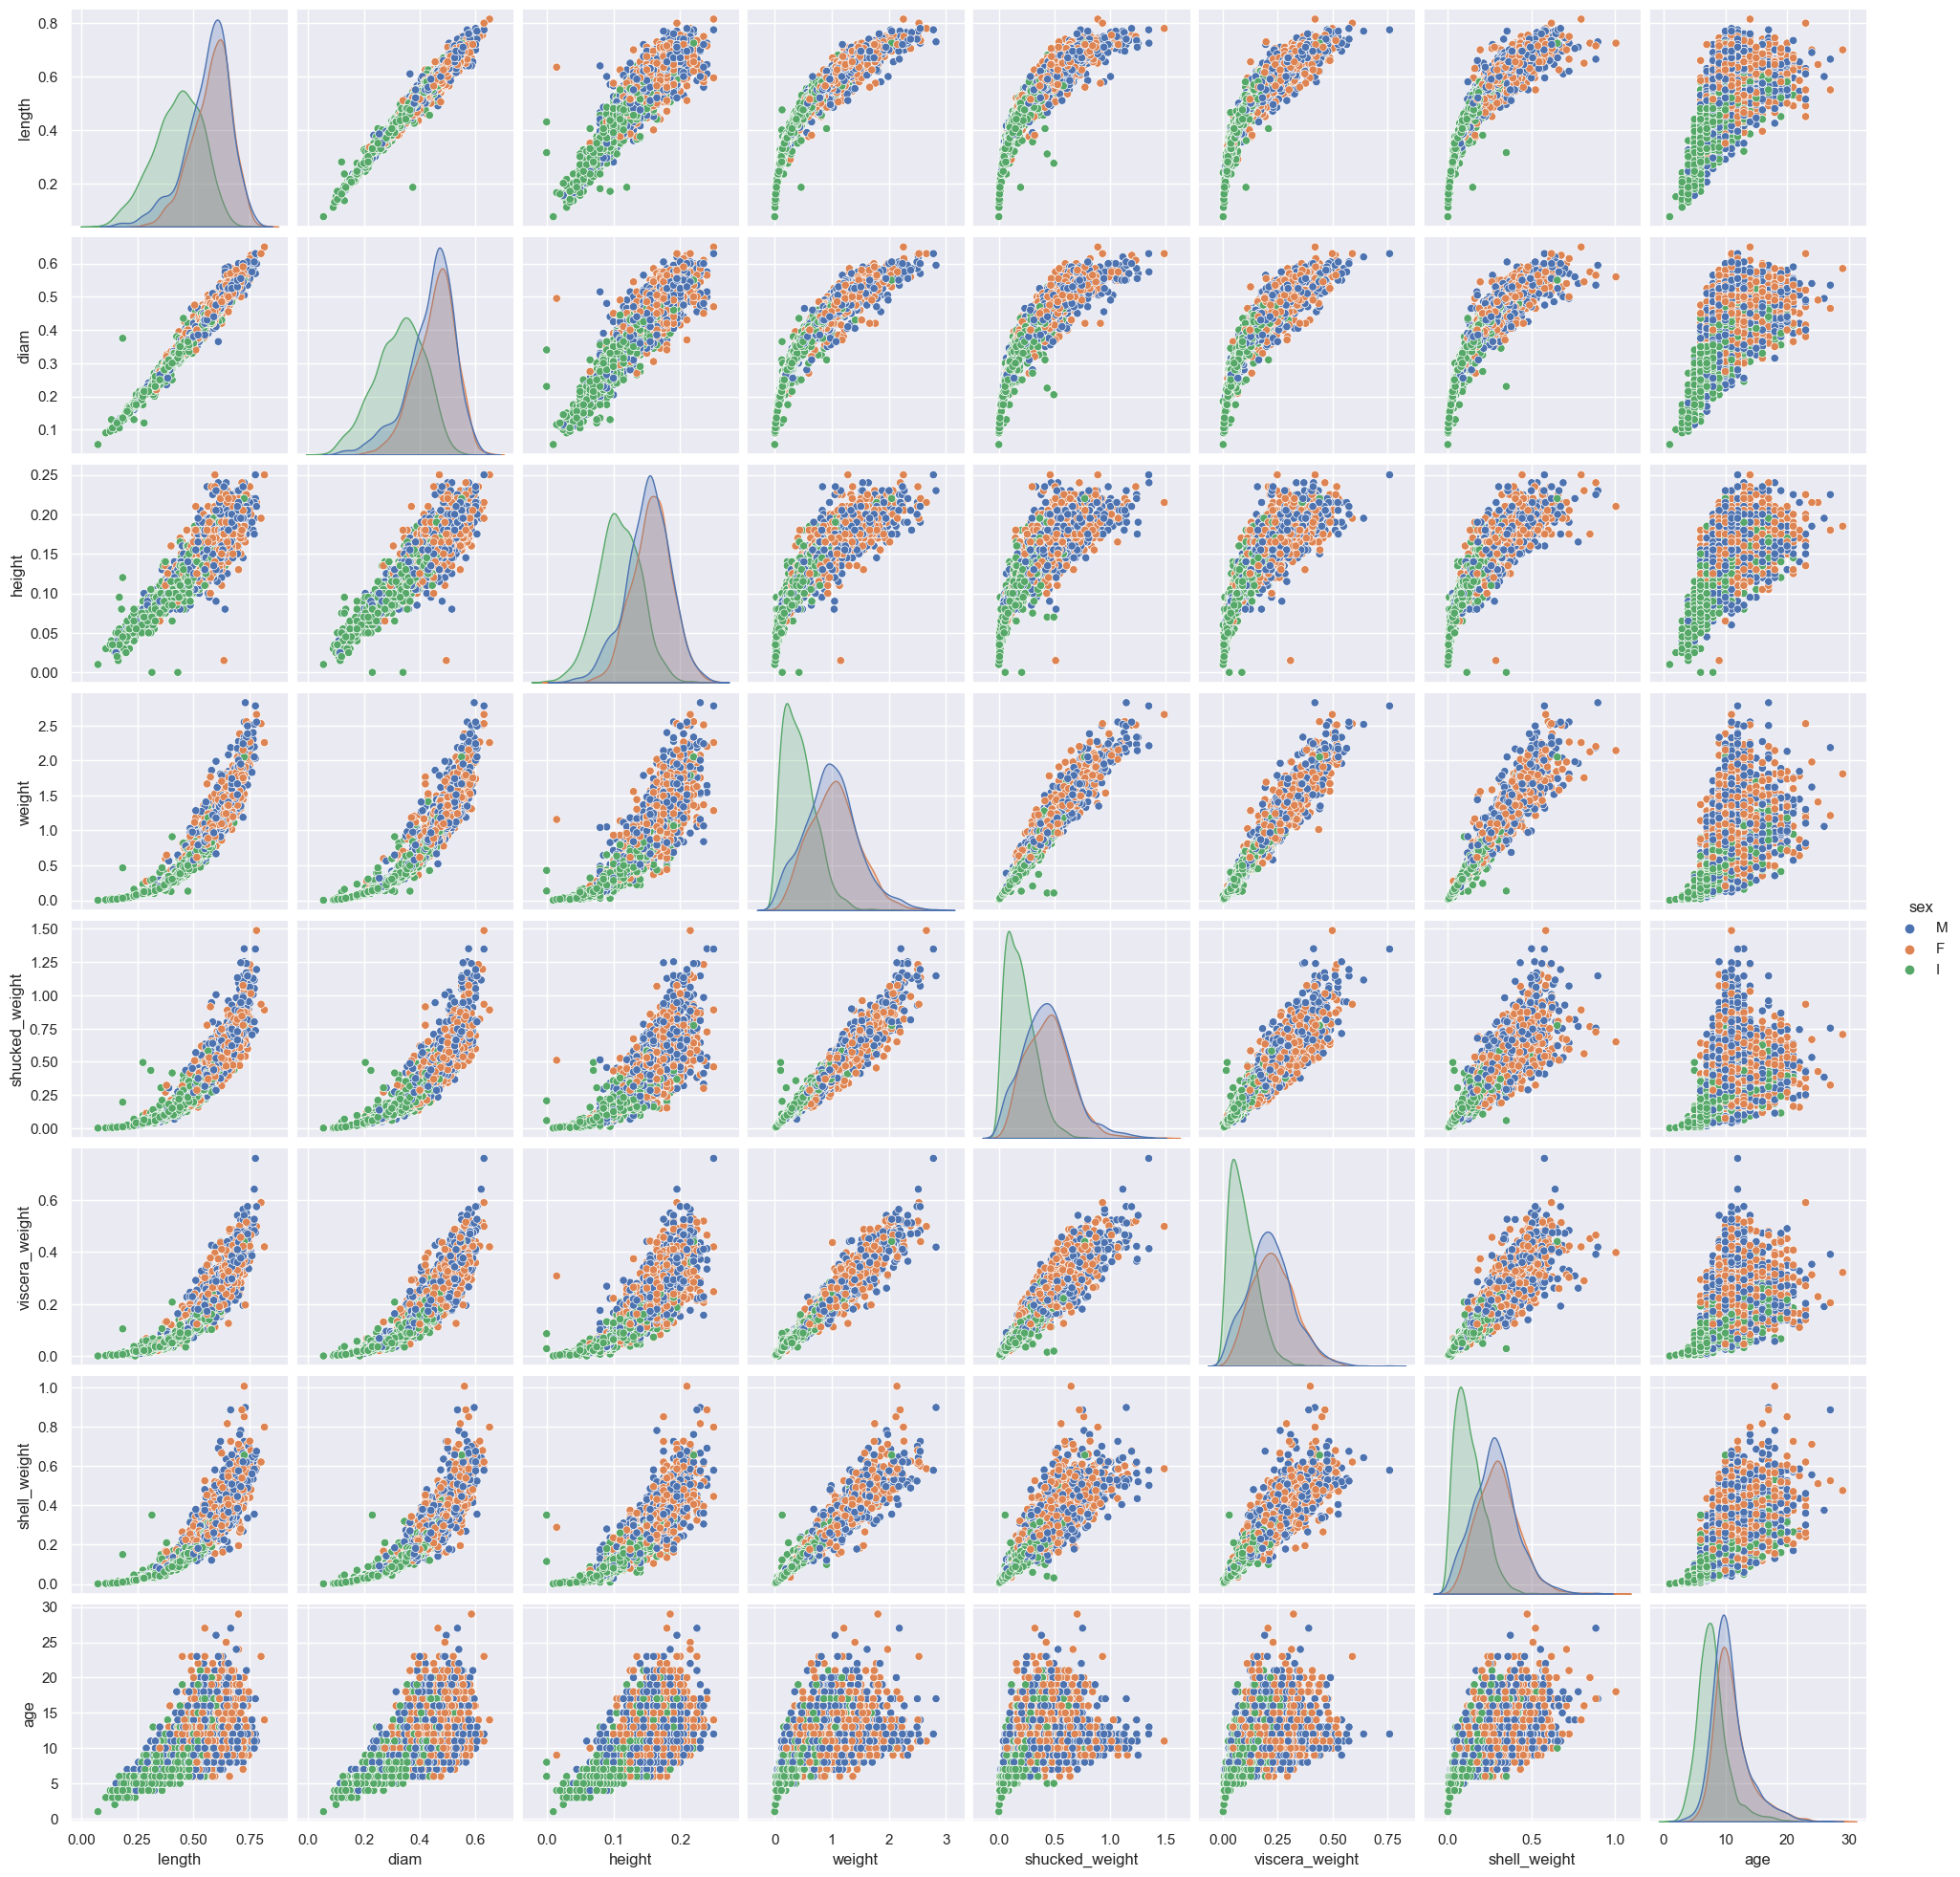

In [17]:
_ = sns.pairplot(df, hue="sex")

There are certainly a lot of correlations, but the age variable becomes less predictable as you get into the higher values of the independent variables, and it fans out visually.

### Preprocessing

Time to start modeling? Close... we need to preprocess the data. Our preprocessing work is minimal, because the data is already mostly numerical, but the sex category must be label-encoded.

In [18]:
from sklearn import preprocessing

le = preprocessing.LabelEncoder()
le.fit(df['sex'])
tf = le.transform(df['sex'])
df['sex'] = tf
df.head()

,sex,length,diam,height,weight,shucked_weight,viscera_weight,shell_weight,age
0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


Next, separate our independent and dependent variables into the X matrix and y vector.

In [19]:
array = df.values
X = array[:,:8]
y = array[:,8]

And finally, split our data into a train and test set, to determine when our model might be overfitting, and respond accordingly.

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=.3, shuffle=True, random_state=123)

# Modeling

Now, let's see how a basic multiple regression model performs.

In [22]:
model = linear_model.LinearRegression()
_ = model.fit(X_train, y_train)

We can view the intercept and coefficient values...

In [26]:
print(model.intercept_)
print()
print(model.coef_)

2.3833422138688327

[  0.07865834   1.12806014   8.42823454  22.37328765   8.94575046
 -19.33077277 -11.21022763   7.87052554]


And we can plot the y values vs. the predictions:

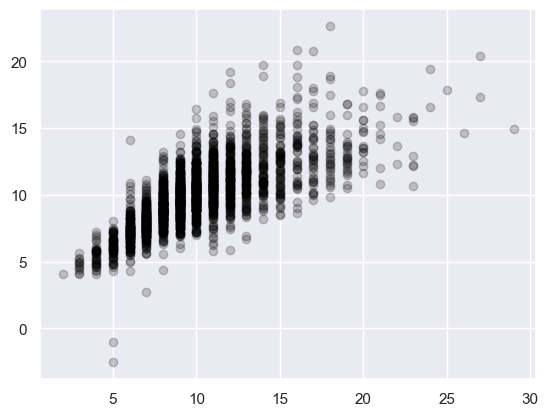

In [35]:
plt.scatter(y_train, pred, color='black', alpha=0.2);

We can also check the correlation of the actuals and predictions. We see that it's quite high.

In [38]:
r = pearsonr(y_train.squeeze(),pred.squeeze())
r

PearsonRResult(statistic=0.7332479775753037, pvalue=0.0)

But with multiple regression, we tend to rely on other measures.

### Coefficient of Determination

For multiple regression, the coefficient of determination, $R^2$, is more important than the correlation. $R^2$ explains the proportion of variance in the dependent variables that can be explained by the predictor variables. It is equal to the sum of squares of the residuals divided by the total sum of squares.

$$R^2 - 1 - \frac{SS_{res}}{SS_{tot}}$$

Scikit-learn has the following implementation.

In [39]:
from sklearn.metrics import r2_score

R2 = r2_score(y_train, pred.squeeze())
print(R2)

0.5376525966182726


We can see that it does indeed equal to the square of our $r$ value.

In [44]:
r[0]**2

0.537652596618273

Other error metrics for measuring goodness of fit include mean absolute deviation, mean squared error, and root mean squared error. They are used to compare two datasets - namely, the predictions and the actuals.

### Mean Absolute Error

Mean absolute error is simply the average of the amount of error for each observation, in this case represented by the difference between our actuals and our predictions.

$$MAE = \frac{ \sum_i^n |\hat{y_i} - y_i| }{ n }$$

In [45]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_train, pred)
print(mae)

1.597314118374394


### Mean Squared Error (MSE)

Mean squared error is the average of the difference between the actual and predicted values squared.

$$MSE = \frac{1}{n} \sum_{i=1}^n(y_i - \hat{y}_i)^2$$

In [46]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_train, pred)
print(mse)

4.838732592655396


We could also code it from scratch.

In [48]:
diff = np.subtract(y_train, pred)
sqre_err = np.square(diff)
mse = sqre_err.mean()
print(mse)

4.838732592655396


### Root Mean Squared Error

MSE squares our residuals, and RMSE puts it back into the original units by taking the square root, making it more intuitive to interpret.

In [49]:
np.sqrt(mse)

2.1997119340166784

In [53]:
diff = np.subtract(y_train, pred)
sqre_err = np.square(diff)
mse = sqre_err.mean()
rmse = sqrt(mse)
print(rmse)

2.1997119340166784


Let's arbitrarily choose RMSE as our favorite metric, and see what the results on the test set look like, as compared to results on the train set.

In [58]:
test_pred = model.predict(X_test)
mse = mean_squared_error(y_test, test_pred)
rmse = sqrt(mse)
print(rmse)

2.204612670478529


The RMSE upon the test set is very similar, suggesting that the model generalizes equally well (or poorly) upon data it hasn't seen - i.e., it does not seem to have overfit. But what if it did, or if we simply want to attempt to tune the model in order to improve results further?

Spoiler alert - there is a such thing as penalized regression, in which there are hyperparameters to tune, and this can get us better results. We'll get there, with grid search, but first need to discuss the measurement of performance. When comparing hyperparameters, we'll want to minimize the impact of random variability in the train and test data selections, as this will mimic the conditions of dealing with unseen data in the wild.

# Cross-Validation

The concept behind cross-validation is similar to data splitting (into a train and test set). We don't want to use our test set for the sake of tuning our model, because then it is no longer unseen data, and will not be able to tell us how well our model truly generalizes in the end. 

Instead, we hold back the test data until the very end, and split our training set into two segments, over and over at random (shuffling the data). The shuffles can be stratified if there is important class information. Each time, we make predictions upon the validation data based on training from the training data, and we consider the model's performance (and variability) over multiple trials instead of one. 

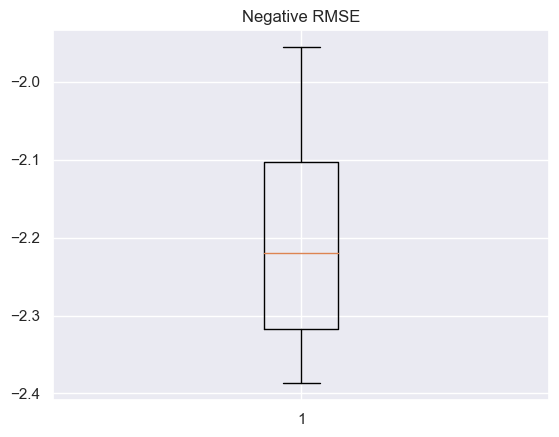

In [71]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

model.fit(X_train, y_train)
kfold = KFold(n_splits=10, shuffle=True, random_state=123)
cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='neg_root_mean_squared_error')

ax = fig.add_subplot(111)
plt.boxplot(cv_results)
plt.title('Negative RMSE')
plt.show()

RMSE was slightly higher that 2.2 on average, but you can see that there was also some variability. Note that as a matter of preference, scikit-learn has expressed it as negative RMSE, changing the sign and therefore the direction which is good.

# Penalized Regression

### Lasso Regression

Lasso stands for least absolute shrinkage and selection operator, and Lasso regression is an extension of linear regression where the loss (error) function is modified to minimize the complexity of the model, measured as the sum of the absolute values of the coefficients. This is called the L1 norm.

<p>$$SSE_{L_1} = \sum_{i=1}^n (y_i - \hat{y})^2 + \alpha \sum_{j=1}^P |B_j|$$</p>

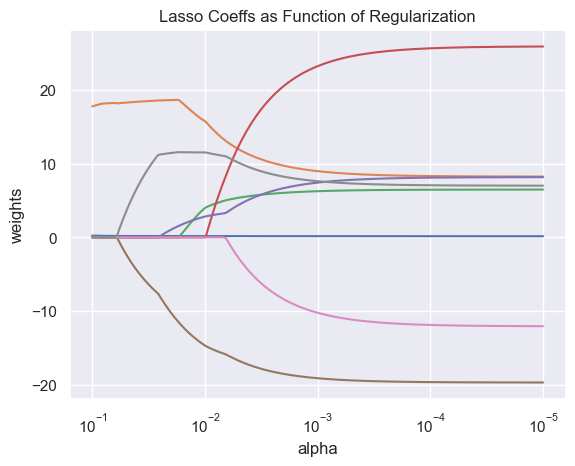

In [74]:
import warnings
warnings.filterwarnings("ignore")

n_alphas = 200
alphas = np.logspace(-5, -1, n_alphas)

coefs = []
for a in alphas:
    lasso = linear_model.Lasso(alpha=a, fit_intercept=False)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)
    
ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale("log")
ax.set_xlim(ax.get_xlim()[::-1])  # reverse axis
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Lasso Coeffs as Function of Regularization")
plt.axis("tight")
plt.show()

The above shows that by adjusting the L1 alpha value, some variables' coefficients become lower and others become more prevalent.

### Ridge Regression

<p>Ridge regression is similar to Lasso regression; the loss function is modified to minimize the complexity of the model, but this time measured as the sum of the squared value of the coefficient values (a.k.a. the $L2$ norm). It too adds a penalty on the sum of the squared regression parameters:</p>

<p>$$SSE_{L_2} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^P \beta_j^2$$</p>

<p>The effect of the penalty is that the parameter estimates are only allowed to become large if there is a proportional reduction in SSE. Like with Lasso, under cross-validation, the penalty (alpha) value can be optimized effectively.</p>

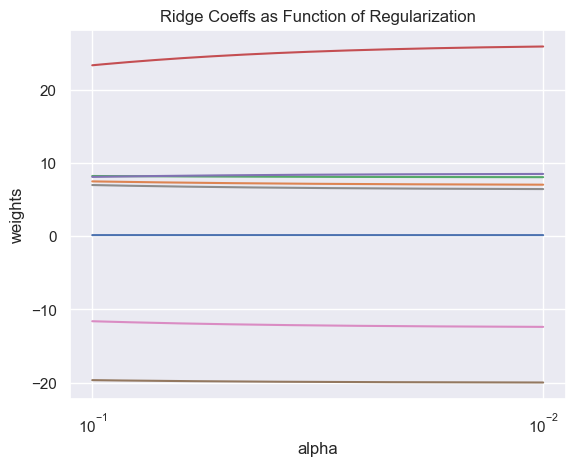

In [77]:
from sklearn import linear_model

n_alphas = 200
alphas = np.logspace(-2, -1, n_alphas)

coefs = []
for a in alphas:
    ridge = linear_model.Ridge(alpha=a, fit_intercept=False)
    ridge.fit(X_train, y_train)
    coefs.append(ridge.coef_)
    
ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale("log")
ax.set_xlim(ax.get_xlim()[::-1])  # reverse axis
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Ridge Coeffs as Function of Regularization")
plt.axis("tight")
plt.show()

The results upon our dataset our not so interesting! But they can be with other datasets. 

### Elastic-Net Regression

We will focus on tuning our alpha parameter for Lasso, but before disregarding Ridge regression, I will introduce Elastic-Net regression, which incorporates both an L1 and L2 penalty into its loss function for evaluating the model coefficients.

<p>$$SSE_{Enet} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^P \beta_j^2 + \alpha \sum_{j=1}^P |B_j|$$</p>

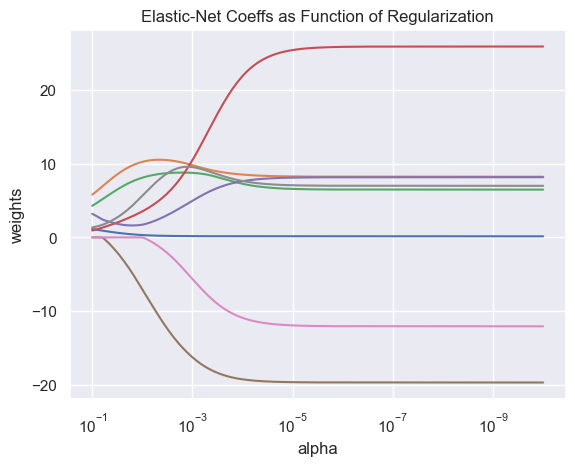

In [78]:
import warnings
warnings.filterwarnings("ignore")

n_alphas = 200
alphas = np.logspace(-10, -1, n_alphas)

coefs = []
for a in alphas:
    enet = linear_model.ElasticNet(alpha=a, fit_intercept=False)
    enet.fit(X_train, y_train)
    coefs.append(enet.coef_)
    
ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale("log")
ax.set_xlim(ax.get_xlim()[::-1])  # reverse axis
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Elastic-Net Coeffs as Function of Regularization")
plt.axis("tight")
plt.show()

# Grid Search

Finally, let's see if we can improve the performance of our model by selecting better hyperparameter values. The below loops through iterations of shuffled data with cross-validation, and determines the rate of error based on the magnitude of alpha value.

100: -3.232587 (0.156324)
10: -3.232587 (0.156324)
1.0: -3.232587 (0.156324)
0.5: -2.892356 (0.174436)
0.1: -2.713684 (0.186770)
0.05: -2.569552 (0.185066)
0.01: -2.271050 (0.145730)
0.005: -2.238682 (0.142953)
0.001: -2.207601 (0.134810)
0.0001: -2.206545 (0.132638)
0: -2.206564 (0.132391)


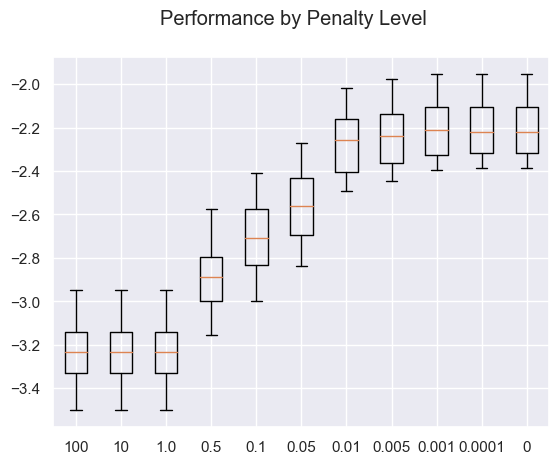

In [87]:
model = linear_model.Lasso()
alphas = [100, 10, 10e-1, 5e-1, 10e-2, 5e-2, 10e-3, 5e-3, 10e-4, 10e-5, 0]
results = []

for a in alphas:
    model.alpha = a
    model.fit(X_train, y_train)
    kfold = KFold(n_splits=10, shuffle=True, random_state=123)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='neg_root_mean_squared_error')
    results.append(cv_results)
    msg = "%s: %f (%f)" % (a, cv_results.mean(), cv_results.std())
    print(msg)
    
fig = plt.figure()
fig.suptitle('Performance by Penalty Level')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(alphas)
plt.show()

Error is greater in magnitude with the lower values of alpha (since we are looking at negative RMSE). It appears that if we are sticking with a basic linear regression model, that the best performance is achieved on this dataset without really utilizing a penalized model. Again, our test set RMSE is as follows:

In [86]:
test_pred = model.predict(X_test)
mse = mean_squared_error(y_test, test_pred)
rmse = sqrt(mse)
print(rmse)

2.2046126745295735


# What Next?

Can better results be achieved? We have only scratched the surface of the available types of models, and we haven't explored the possibility of framing this as a classification question. But the scope of this article is limited to linear regression, so I will end it here, and hope that you have found it useful of inspiring.